In [1]:
import os
import time
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


d:\App\python\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
sns.set_style("whitegrid")
tf.keras.utils.set_random_seed(123)

KFOLD_DIR = r'D:/Do_An/Data_Final/kfold_splits' 
SAVE_DIR = r'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = 224 
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 20
K_FOLDS = 5

UNFREEZE_PERCENT = 0.25       
LR_PHASE2 = 1e-5

In [3]:
# DATA AUGMENTATION
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

# Chỉ chuẩn hóa (preprocess) cho tập Val và Test
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [4]:
# XÂY DỰNG MÔ HÌNH (FINE-TUNING)
def build_model():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Freeze toàn bộ ở Phase 1
    for layer in base_model.layers:
        layer.trainable = False
    
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

In [5]:
def unfreeze_model(base_model):
    total_layers = len(base_model.layers)
    unfreeze_from = int(total_layers * (1 - UNFREEZE_PERCENT))

    print(f"Unfreeze từ layer {unfreeze_from}/{total_layers}")

    for i, layer in enumerate(base_model.layers):
        layer.trainable = i >= unfreeze_from

    # Freeze BatchNorm (quan trọng)
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

In [6]:
def train_one_fold(fold):
    print(f"\nTRAIN FOLD {fold}/5")

    fold_dir = os.path.join(KFOLD_DIR, f'fold_{fold}')

    train_gen = train_datagen.flow_from_directory(
        os.path.join(fold_dir, 'train'),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_gen = val_test_datagen.flow_from_directory(
        os.path.join(fold_dir, 'val'),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        os.path.join(fold_dir, 'test'),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    model, base_model = build_model()

    # CALLBACKS 
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1   
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f'EffB0_Fold_{fold}_best.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

    # PHASE 1 
    print("\nPHASE 1: Train Head")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    h1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE1,
        callbacks=callbacks,
        verbose=1
    )

    #PHASE 2
    print("\nPHASE 2: Fine-tuning")

    unfreeze_model(base_model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_PHASE2),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    h2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE2,
        callbacks=callbacks,
        verbose=1
    )

    # EVALUATE 
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)

    print(f"Fold {fold} - Test Accuracy: {test_acc*100:.2f}% | Loss: {test_loss:.4f}")

    # HISTORY
    history = {
        'loss': h1.history['loss'] + h2.history['loss'],
        'val_loss': h1.history['val_loss'] + h2.history['val_loss'],
        'accuracy': h1.history['accuracy'] + h2.history['accuracy'],
        'val_accuracy': h1.history['val_accuracy'] + h2.history['val_accuracy']
    }

    final_val_loss = history['val_loss'][-1]

    return test_acc, history, test_gen, final_val_loss

In [7]:
start_time = time.time()

accs = []
val_losses = []
histories = []
test_gens = []

for fold in range(1, K_FOLDS + 1):

    fold_start = time.time()
    
    acc, hist, test_gen, val_loss = train_one_fold(fold)

    accs.append(acc)
    val_losses.append(val_loss)
    histories.append(hist)
    test_gens.append(test_gen)

    fold_time = time.time() - fold_start
    print(f"Fold {fold} time: {fold_time:.2f}s")


max_acc = max(accs)

candidates = [i for i, acc in enumerate(accs) if acc == max_acc]

best_idx = min(candidates, key=lambda i: val_losses[i])

best_fold_idx = best_idx + 1
best_acc = accs[best_idx]

best_history = histories[best_idx]
best_test_gen = test_gens[best_idx]
best_model_path = os.path.join(SAVE_DIR, f'EffB0_Fold_{best_fold_idx}_best.keras')

total_time = time.time() - start_time
h, rem = divmod(total_time, 3600)
m, s = divmod(rem, 60)


TRAIN FOLD 1/5
Found 1876 images belonging to 2 classes.
Found 331 images belonging to 2 classes.
Found 552 images belonging to 2 classes.

PHASE 1: Train Head
Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.8961 - loss: 0.2528
Epoch 1: val_accuracy improved from None to 0.97281, saving model to saved_models\EffB0_Fold_1_best.keras

Epoch 1: finished saving model to saved_models\EffB0_Fold_1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 63s 935ms/step - accuracy: 0.9440 - loss: 0.1683 - val_accuracy: 0.9728 - val_loss: 0.1087 - learning_rate: 0.0010
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.9696 - loss: 0.0913
Epoch 2: val_accuracy improved from 0.97281 to 0.98489, saving model to saved_models\EffB0_Fold_1_best.keras

Epoch 2: finished saving model to saved_models\EffB0_Fold_1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 868ms/step - accuracy: 0.9733 - loss: 0.0729 - val_accuracy: 0.9849 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 3/15
59/59 ━━━━━━━

In [8]:
max_acc = max(accs)
candidates = [i for i, acc in enumerate(accs) if acc == max_acc]
best_idx = min(candidates, key=lambda i: val_losses[i])

best_fold = best_idx + 1
best_acc = accs[best_idx]

results = pd.DataFrame({
    "Fold": list(range(1, K_FOLDS + 1)),
    "Accuracy": accs,
    "Val_Loss": val_losses
})

print(results)

print("\nKẾT QUẢ")
print(f"Mean Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Best Fold: {best_fold} (Acc = {best_acc:.4f}, Val_loss = {val_losses[best_idx]:.4f})")
print(f"Total time: {int(h)}h {int(m)}m {int(s)}s")

   Fold  Accuracy  Val_Loss
0     1  1.000000  0.003807
1     2  0.998188  0.003695
2     3  0.990942  0.010717
3     4  1.000000  0.006677
4     5  1.000000  0.000593

KẾT QUẢ
Mean Accuracy: 0.9978 ± 0.0035
Best Fold: 5 (Acc = 1.0000, Val_loss = 0.0006)
Total time: 2h 1m 57s


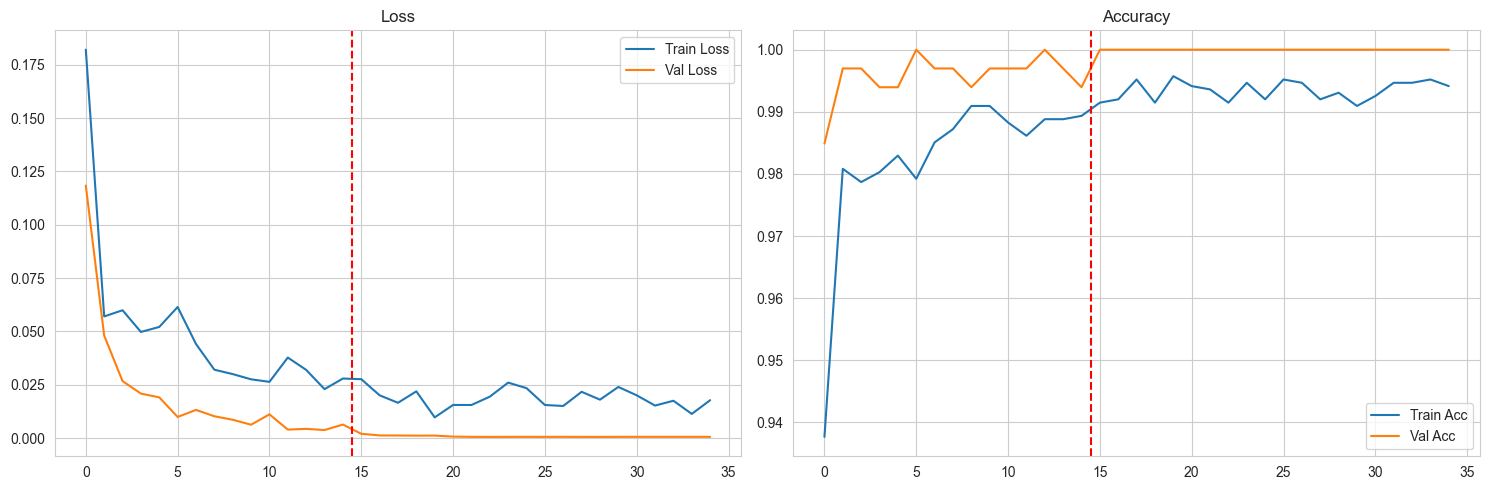

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(best_history['loss'], label='Train Loss')
ax1.plot(best_history['val_loss'], label='Val Loss')
ax1.axvline(x=EPOCHS_PHASE1 - 0.5, color='red', linestyle='--')
ax1.legend()
ax1.set_title("Loss")

ax2.plot(best_history['accuracy'], label='Train Acc')
ax2.plot(best_history['val_accuracy'], label='Val Acc')
ax2.axvline(x=EPOCHS_PHASE1 - 0.5, color='red', linestyle='--')
ax2.legend()
ax2.set_title("Accuracy")

plt.tight_layout()
plt.show()

In [10]:
model = build_model()[0]  # lấy model
model.load_weights(best_model_path)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== RESET GENERATOR =====
best_test_gen.reset()

# ===== PREDICT =====
pred_probs = model.predict(best_test_gen)

# binary -> class
pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)

true_classes = best_test_gen.classes

# class names
class_names = list(best_test_gen.class_indices.keys())

18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 721ms/step


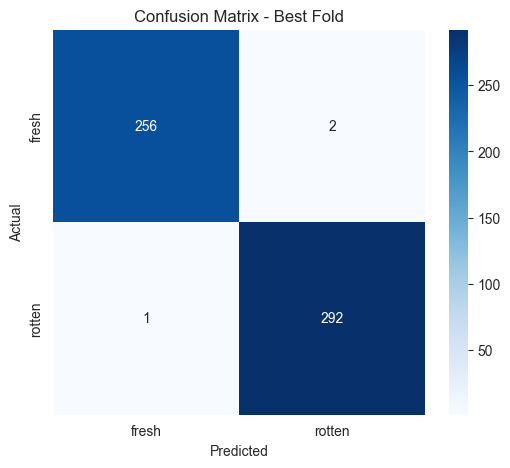

In [11]:
# Ma Trận Nhầm Lẫn (Confusion Matrix)
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Best Fold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
# Classification Report
print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

       fresh       1.00      0.99      0.99       258
      rotten       0.99      1.00      0.99       293

    accuracy                           0.99       551
   macro avg       0.99      0.99      0.99       551
weighted avg       0.99      0.99      0.99       551



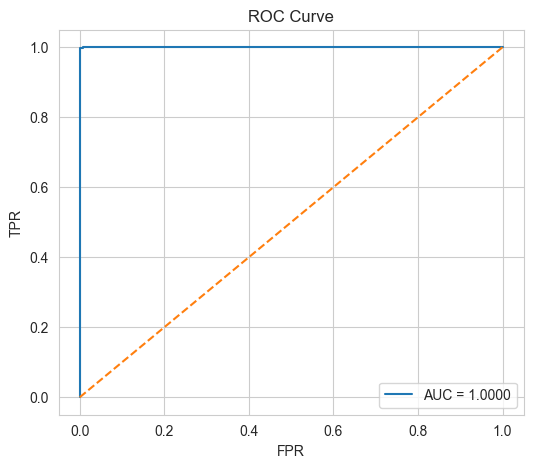

In [13]:
# ROC Curve
fpr, tpr, _ = roc_curve(true_classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()



Có 3 ảnh dự đoán sai


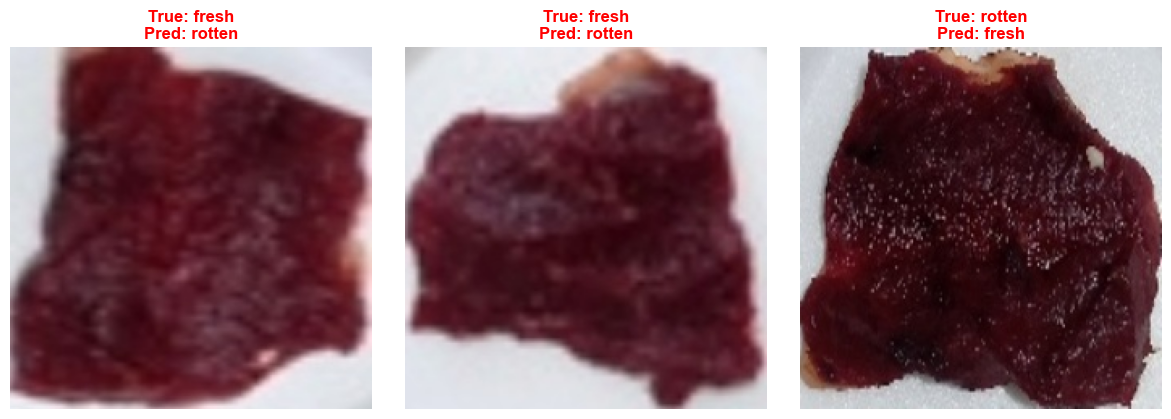

In [ ]:
# Ảnh Dự Đoán Sai
misclassified = np.where(pred_classes != true_classes)[0]

if len(misclassified) > 0:
    print(f"\nCó {len(misclassified)} ảnh dự đoán sai")

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(misclassified[:6]):  
        img_path = best_test_gen.filepaths[idx]
        img = plt.imread(img_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(
            f"True: {class_names[true_classes[idx]]}\nPred: {class_names[pred_classes[idx]]}",
            color='red', fontweight='bold'
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("\nModel dự đoán đúng toàn bộ test set")

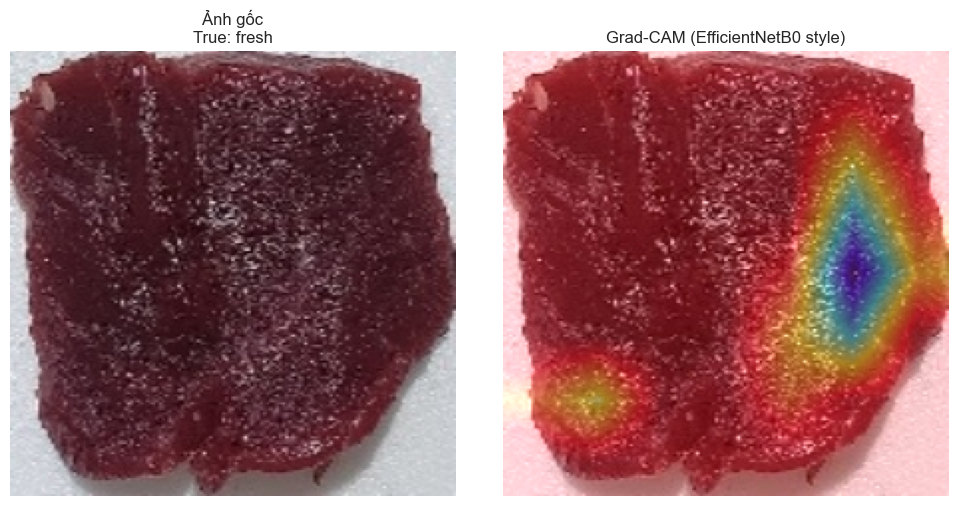

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Tính toán Gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # 3. Tính toán độ quan trọng của các kênh (Channel Importance)
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    # Nhân trọng số vào các feature map
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 4. ReLU và Chuẩn hóa (0.0 - 1.0)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val.numpy() == 0:
        return np.zeros(heatmap.shape)

    heatmap /= max_val
    return heatmap.numpy()

last_conv_layer_name = "top_conv" 

# Chọn ảnh từ generator của bạn
target_idx = 0 # Bạn có thể đổi thành misclassified[0] nếu muốn
img_path = best_test_gen.filepaths[target_idx]

# 1. Preprocess ảnh
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array) # Dùng đúng preprocess của EfficientNet

# 2. Tạo Heatmap (Dùng model_final là model EfficientNet đã load)
heatmap = make_gradcam_heatmap(img_array, model_final, last_conv_layer_name)

# 3. Đọc ảnh gốc để hiển thị
img_orig = np.array(Image.open(img_path).convert("RGB"))

# 4. HẬU XỬ LÝ ĐỂ RA MÀU RỰC RỠ (Phong cách MobileNetV2)
# Resize heatmap về bằng kích thước ảnh gốc
heatmap_resized = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)

# Sử dụng bảng màu JET (Xanh -> Đỏ)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Trộn ảnh (Overlay) - Giữ nguyên công thức 0.4 như bạn muốn
superimposed_img = heatmap_color * 0.4 + img_orig
superimposed_img = np.uint8(np.clip(superimposed_img, 0, 255))

# 5. HIỂN THỊ
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_orig)
plt.title(f"Ảnh gốc\nTrue: {class_names[best_test_gen.labels[target_idx]]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM (EfficientNetB0 style)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
print(f"\nĐã lưu biểu đồ tất cả các fold tại: {SAVE_DIR}/All_Folds_Loss_Accuracy.png")
print(f"Best model được lưu tại: {SAVE_DIR}/EffB0_Fold_{best_fold}_best.keras")


Đã lưu biểu đồ tất cả các fold tại: saved_models/All_Folds_Loss_Accuracy.png
Best model được lưu tại: saved_models/EffB0_Fold_5_best.keras
